In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
from scipy.signal import convolve
import scipy
from joblib import Parallel, delayed
import time
import sys
from scipy import sparse
import json
from tqdm import tqdm, tqdm_notebook
import matplotlib.gridspec as gridspec
from copy import deepcopy
import os
sys.path.insert(0, "../Scripts")
# from antigenicWaveSimulationMethods import main as coEvoSimulation
from coverage import elementwise_coverage, coverage_1D
from fitness import fitness, norm_fitness, phage_growth
# from altImmunity import immunity_loss_uniform, immunity_gain_from_kernel
from immunity import immunity_mean_field_add, immunity_mean_field_remove
from initMethods import init_trail_nh, init_1D_kernel, init_guassian_n, init_cond
from supMethods import time_conv, write2json
from mutation import mutation
from randomHGT import HGT_logistic_event


In [25]:
params = { #parameters relevant for the equations
        "Nh":                    10E4,
        "N0":                     1E9, #This Will be updated by self-consitent solution
        "R0":                      20, 
        "M":                        3, #Also L, total number of spacers
        "mu":                      50, #mutation rate
        "gamma_shape":             20,
        "Np":                     100, #Number of Cas Protein
        "dc":                      10, #Required number of complexes to activate defence
        "h":                       10, #coordination coeff
        "r":                     1000, #cross-reactivity kernel
        "beta":                     0.05,
        "rate_HGT":                 0,
        "HGT_bonus_acq_ratio":      0,
        "rate_recovery":            0,
        "HGT_type":                 0,
        "n_spacer":                 1,
        "A":                        1,
    }
sim_params = { #parameters relevant for the simulation (including Inital Valuess)
        "continue":                 False, #DO NOT CREATE ARBITRARY FOLDERS ONLY FOR TESTS
        "xdomain":                  50000,
        "dim":                          1,
        "dx":                           1,
        "tf":                        1000,
        "dt":                           1,
        "dt_exact_fitness":             1,
        "dt_snapshot":                  1,
        "initial_mean_n":           [0,0],
        "initial_mean_nh":          [0,0],
        "conv_size":                 2000,
        "num_threads":                 32,
        "foldername":                "../",
        "seed":                         34,
        "hard_N0":                   False,
        "ndim":                         1,
    }

In [26]:
from supMethods import minmax_norm
from initMethods import find_root_fitness, return_v_tau
from fitness import derivative_fitness
from formulas import theoretical_c, fitness_linear_approx, fitness_simple_M, gaussian1D

In [27]:
# params["beta"] = 0.1
params, sim_params = init_cond(params, sim_params, out_print=True, assumption_check=True)

Phage Population: 1000000000.0000| Uc: 401.3949| sigma: 75.6651
Phage Population: 15145.0334| Uc: 220.9757| sigma: 65.1762
Phage Population: 34651.2039| Uc: 236.6128| sigma: 66.2998
Phage Population: 24195.5548| Uc: 229.8925| sigma: 65.8240
Phage Population: 24679.0163| Uc: 230.2652| sigma: 65.8506
Phage Population: 24339.4834| Uc: 230.0042| sigma: 65.8320
Phage Population: 24345.5067| Uc: 230.0089| sigma: 65.8323
Phage Population: 24331.8758| Uc: 229.9983| sigma: 65.8315
Phage Population: 24331.5655| Uc: 229.9977| sigma: 65.8315
Assumptions Checks: 
mu >> 1 : mu = 50 >> 1
del_x << r : gamma_shape = 20 << r = 1000
v*tau >> sigma : v*tau = 274.83231464755045 >> sigma = 65.83149380476004
uc << r : uc = 229.99766380475782 << r = 1000
uc_delayed >> beta_sigma**2 : uc delayed = 229.99766380475782 >> beta_sigma**2 = 216.689278828308


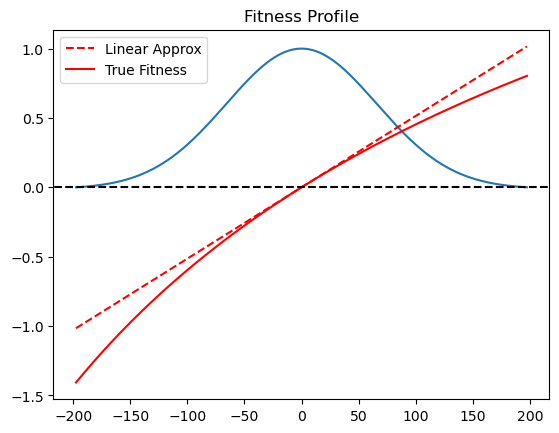

In [28]:
fig, ax = plt.subplots()

sigma_n = params["sigma"]
x= np.arange(-3*sigma_n, 3*sigma_n, 0.1)
ax.plot(x, minmax_norm(gaussian1D(x, 0, params,sim_params, delay=False)))
# plt.plot(x, minmax_norm(trail_exp(x, 0, params,sim_params)))

c = theoretical_c(x, 0, params, sim_params, direction="Full")
# plt.plot(x, c, label = "Proj. Approx")
ax.plot(x, fitness_linear_approx(x, 0, params, sim_params), color = "red", linestyle = "--",label = "Linear Approx")

ax.plot(x, fitness_simple_M(c, params, sim_params), color = "red", label = "True Fitness")

# plt.plot(x, fitness_simple_M(c, params, sim_params, M ), color = "orange", label = "M = 20")
ax.axhline(0, np.min(x), np.max(x), linestyle= "--", color = "k")
ax.set_title("Fitness Profile")
ax.legend()

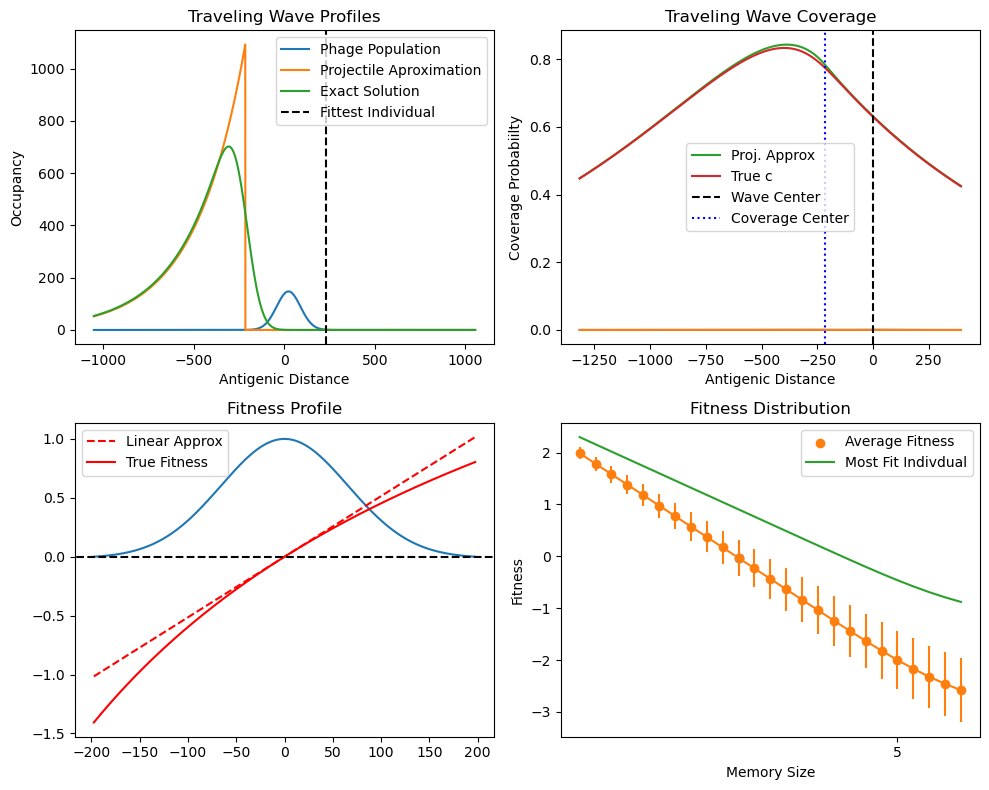

In [29]:
from formulas import plot_fitness_memory_dynamics, plot_wave_coverage, plot_wave_fitness, plot_wave_profiles
fig = plt.figure(figsize=(10, 8))

# Define the grid layout with 3 rows and 3 columns
gs = gridspec.GridSpec(2, 2)

# Create the first two rows (2x2 grid)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Plot something in each subplot
plot_wave_profiles(params, sim_params, ax1)
plot_wave_coverage(params, sim_params, ax2)
plot_wave_fitness(params, sim_params, ax3)
plot_fitness_memory_dynamics(params, sim_params, ax4)

# Adjust the layout
plt.tight_layout()

# Display the plot
plt.show()

In [19]:
params

{'Nh': 1000000.0,
 'N0': 1513728,
 'R0': 20,
 'M': 3,
 'mu': 50,
 'gamma_shape': 20,
 'Np': 100,
 'dc': 10,
 'h': 10,
 'r': 1000,
 'beta': 0.01,
 'rate_HGT': 0,
 'HGT_bonus_acq_ratio': 0,
 'rate_recovery': 0,
 'HGT_type': 0,
 'n_spacer': 1,
 'A': 0.1,
 'N': 1513728,
 'D': 105.0,
 's': 0.005143252849784787,
 'tau': 19.818619989852866,
 'v_tau': 506.5327383013671,
 'v0': 25.5584280697479,
 'sigma': 70.49334715456928,
 'uc': 302.3995312633859,
 'M0': 3,
 'delay': 49.69311993054621}

In [36]:
params["Nh"] = 10e5
# params["mu"] = 50
# params["N0"] = 10e6
# params["A"] = 1

N_values_3_100_10 = []
params["M"] = 3
params["Np"] = 100
params["dc"] = 10
# params["hard_N0"] = False

beta_list = np.power(10, -1*np.arange(1, 3.125, 0.125))
for beta in beta_list:
    params["beta"] = beta
    params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
    N_values_3_100_10.append(params["N"])

N_values_5_100_10 = []
params["M"] = 5
params["Np"] = 100
params["dc"] = 10

beta_list = np.power(10, -1*np.arange(1, 3.125, 0.125))
for beta in beta_list:
    params["beta"] = beta
    params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
    N_values_5_100_10.append(params["N"])

N_values_10_100_10 = []
params["M"] = 10
params["Np"] = 100
params["dc"] = 10

beta_list = np.power(10, -1*np.arange(1, 3.125, 0.125))
for beta in beta_list:
    params["beta"] = beta
    params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
    N_values_10_100_10.append(params["N"])


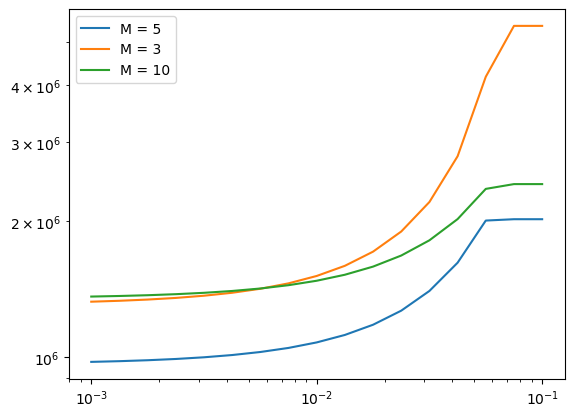

In [41]:
plt.plot(beta_list, N_values_5_100_10, label = "M = 5")
plt.plot(beta_list, N_values_3_100_10, label = "M = 3")
plt.plot(beta_list, N_values_10_100_10, label = "M = 10")
plt.legend()
plt.xscale("log")
plt.yscale("log")

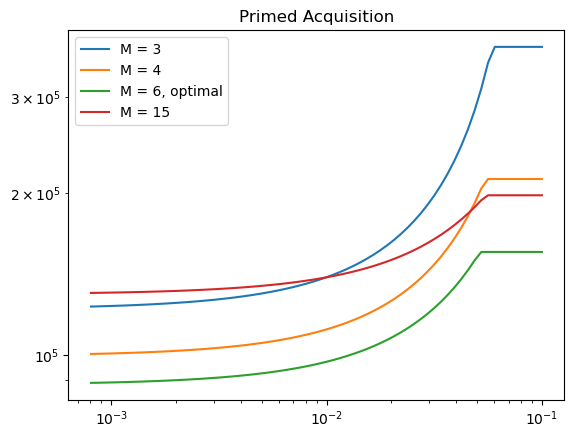

In [30]:
params["Nh"] = 10e5
M_list = [3, 4, 6, 15]
for M in M_list:
    N_values_M_100_10 = []
    params["M"] = M
    params["Np"] = 100
    params["dc"] = 10
    # params["hard_N0"] = False

    beta_list = np.power(10, -1*np.arange(1, 3.125, 0.125/4))
    for beta in beta_list:
        params["beta"] = beta
        params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
        N_values_M_100_10.append(params["N"])
    if M == 6:
        label = f"M = {M}, optimal"
    else:
        label = f"M = {M}"

    plt.plot(beta_list, N_values_M_100_10, label = label)

plt.title("Primed Acquisition")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

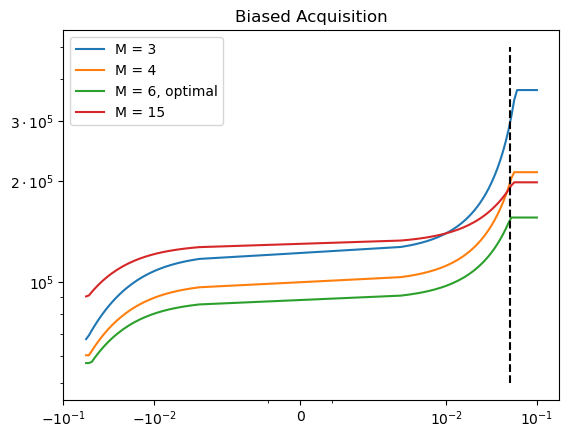

In [149]:
params["Nh"] = 10e4
M_list = [3, 4, 6, 15]
for M in M_list:
    N_values_M_100_10 = []
    params["M"] = M
    params["Np"] = 100
    params["dc"] = 10
    # params["hard_N0"] = False

    beta_list_unprimed = -1*np.power(10, -1*np.arange(1.25, 3.125, 0.125/4))
    beta_list_primed = np.power(10, -1*np.arange(1, 3.125, 0.125/4))[::-1]
    beta_list = np.concatenate([beta_list_unprimed, beta_list_primed])
    for beta in beta_list:
        params["beta"] = beta
        params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
        N_values_M_100_10.append(params["N"])
    if M == 6:
        label = f"M = {M}, optimal"
    else:
        label = f"M = {M}"

    plt.plot(beta_list, N_values_M_100_10, label = label)

plt.title("Biased Acquisition")
# plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale("log")
# plt.yticks([])
plt.yticks([1e5, 2e5, 3e5], [r"$10^5$", r"$2\cdot 10^5$", r"$3\cdot 10^5$"])
plt.xscale("symlog", linthresh = np.power(10, -2.5))
plt.vlines([0.05], 5e4, 5e5, linestyles="--", color = "black")
plt.xticks([-1e-1, -1e-2, 0, 1e-2, 1e-1], [r"$-10^{-1}$", r"$-10^{-2}$", 0, r"$10^{-2}$", r"$10^{-1}$"])
plt.legend()
plt.show()

In [31]:
def coexistence_N_beta_M(beta, M, params, sim_params):
    params = deepcopy(params)
    sim_params = deepcopy(sim_params)
    params["beta"] = beta
    params["M"] = M
    params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
    return params["N"]

def return_vectorized_coexistence_beta_M(params, sim_params):
    def wrapper_coexistence_N_beta_M(beta, M):
        return coexistence_N_beta_M(beta, M, params, sim_params)
 
    return np.vectorize(wrapper_coexistence_N_beta_M)

In [133]:
return_vectorized_coexistence_beta_M(params, sim_params)

In [134]:
beta_list_unprimed = -1*np.power(10, -1*np.arange(1.25, 3.125, 0.125/4))
beta_list_primed = np.power(10, -1*np.arange(1, 3.125, 0.125/4))[::-1]
beta_list = np.concatenate([beta_list_unprimed, beta_list_primed])

m_list = np.arange(3, 15, 0.25)
beta_mesh, m_mesh = np.meshgrid(beta_list, m_list)

N_mesh = return_vectorized_coexistence_beta_M(params, sim_params)(beta_mesh, m_mesh)

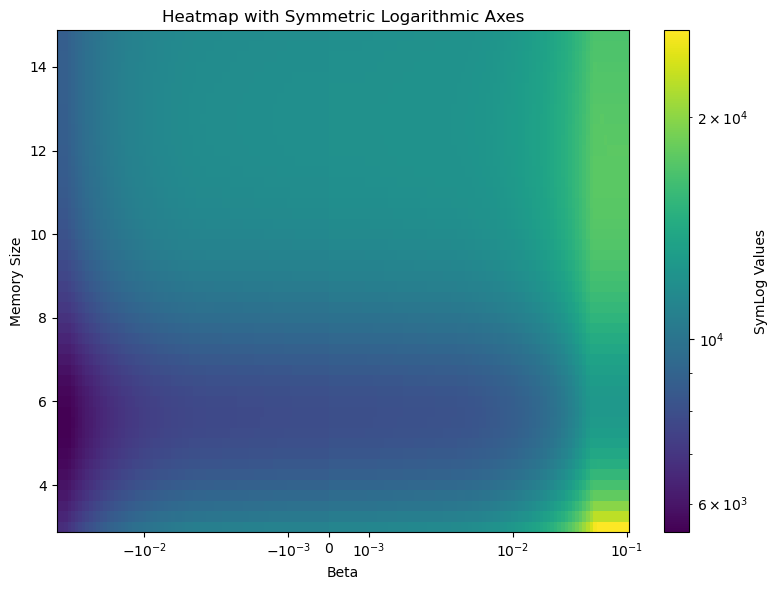

In [147]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(8, 6))

# SymLogNorm for symmetric logarithmic scaling

# Plot the heatmap
norm = LogNorm()
c = ax.pcolormesh(beta_mesh, m_mesh, N_mesh, norm = norm, cmap="viridis", shading='auto')

# Add colorbar with a symmetric logarithmic scale
cbar = fig.colorbar(c, ax=ax)
cbar.set_label("SymLog Values")

# Set symmetric logarithmic scale for the axes
ax.set_xscale('symlog', linthresh=np.power(10, -2.5))
ax.set_yscale("linear")

# Add labels and title
ax.set_xlabel("Beta")
ax.set_ylabel("Memory Size")
ax.set_title("Heatmap with Symmetric Logarithmic Axes")

# Show the plot
plt.tight_layout()
plt.show()

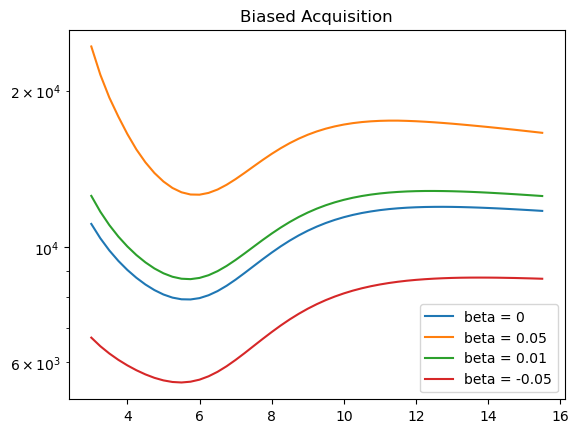

In [32]:
params["Nh"] = 10e4
M_list = np.arange(3, 15.75, 0.25)
beta_list = [0, 0.05, 0.01, -0.05]

for beta in beta_list:
    N_values_M_100_10 = []
    for M in M_list:
        params["M"] = M
        params["Np"] = 100
        params["dc"] = 10
        # params["hard_N0"] = False
        params["beta"] = beta
        params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
        N_values_M_100_10.append(params["N"])

        label = f"beta = {beta}"


    plt.plot(M_list, N_values_M_100_10, label = label)

plt.title("Biased Acquisition")
# plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale("log")

plt.legend()
plt.show()

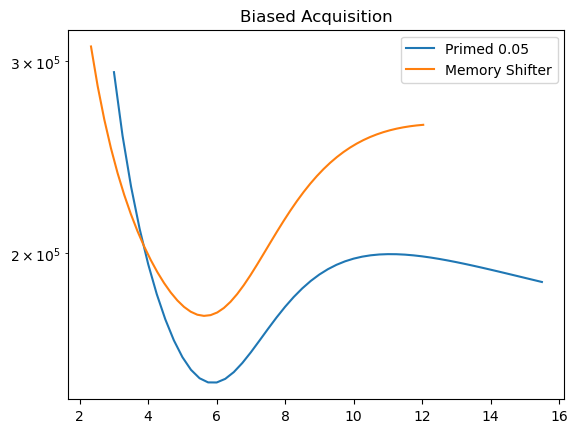

In [163]:
params["Nh"] = 10e4
M_list = np.arange(3, 15.75, 0.25)
beta = 0.05
N_values_M_100_10 = []

for M in M_list:
    params["M"] = M
    params["beta"] = beta

    params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
    N_values_M_100_10.append(params["N"])

delay = params["delay"]
plt.plot(M_list, N_values_M_100_10, label ="Primed 0.05")

M_list_primed = np.exp(-delay/params["r"])*M_list

beta = 0
N_values_M_100_10 = []

for M in M_list_primed:
    params["M"] = M
    params["beta"] = beta

    params, sim_params = init_cond(params, sim_params, out_print=False, assumption_check=False)
    N_values_M_100_10.append(params["N"])

delay = params["delay"]
plt.plot(M_list_primed, 2*np.array(N_values_M_100_10), label ="Memory Shifter")



plt.title("Biased Acquisition")
# plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale("log")

plt.legend()
plt.show()

In [174]:
from scipy.signal import convolve
# sim_params["conv_size"] = 50

beta = 3
params["beta"] = beta
integration_kernel = init_1D_kernel(params, sim_params, "beta")
integration_probability_primed = convolve(nh, integration_kernel, mode="same")

beta = 0
params["beta"] = beta
integration_kernel = init_1D_kernel(params, sim_params, "beta")
integration_probability= convolve(nh, integration_kernel, mode="same")

beta = -0.1
params["beta"] = beta
integration_kernel = init_1D_kernel(params, sim_params, "beta")
integration_probability_forward = convolve(nh, integration_kernel, mode="same")

In [152]:
beta = 1
params["beta"] = beta
integration_kernel = init_1D_kernel(params, sim_params, "beta")
integration_probability = convolve(nh, integration_kernel, mode="same")
# integration_probability = integration_probability*n/np.sum(integration_probability*n)
pi_exact = semi_true_pi(xdomain, 0, params, sim_params, how_true="exact")

(-250.0, 250.0)

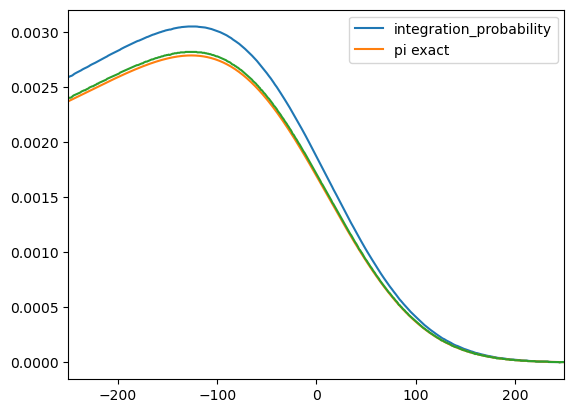

In [153]:
plt.plot(xdomain, integration_probability/np.sum(nh), label = "integration_probability")
plt.plot(xdomain, pi_exact, label = "pi exact")
plt.plot(xdomain, 2*nh/np.sum(nh))
plt.legend()
plt.xlim(-250, 250)

(-250.0, 250.0)

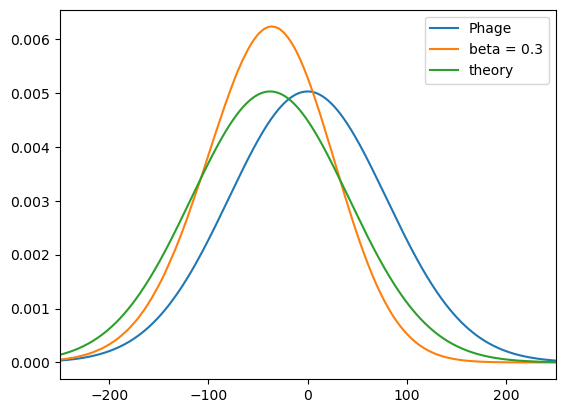

In [154]:
from formulas import gaussian1D

beta = 0.3
params["beta"] = beta
integration_kernel = init_1D_kernel(params, sim_params, "beta")
integration_probability = convolve(nh, integration_kernel, mode="same")
integration_probability = integration_probability*n/np.sum(integration_probability*n)

variance = params["sigma"]**2
v_tau = params["v0"]*params["tau"]
# A1 = np.exp((beta**2)*variance/2)/(1+beta*v_tau)
A1 = 1
A2 = np.exp(beta**2*variance/2)/(1-beta*v_tau)
theory = 0
theory += A2*gaussian1D(xdomain, 0, params, sim_params, mu = -0.02*(beta)*params["sigma"]**2, prob = True)
# theory += A1*gaussian1D(xdomain, 0, params, sim_params, mu = -0.05*(beta)*params["sigma"]**2, prob = True)
theory = theory/np.sum(theory)
phage = gaussian1D(xdomain, 0, params, sim_params, prob = True)

plt.plot(xdomain, phage, label = "Phage")
plt.plot(xdomain, integration_probability, label = f"beta = {beta}")
plt.plot(xdomain, theory, label = "theory")
plt.legend()
plt.xlim(-250, 250)

In [395]:
def init_1D_linear_kernel(params, sim_params, ker_type = "coverage", exponent = 1): #Kernel is all four quadrants
    if ker_type == "coverage" or ker_type == "r":
        kernel = 1./params["r"]
    elif ker_type == "Boltzmann" or ker_type == "beta":
        kernel = params["beta"]
    else:
        raise NotImplementedError
    
    dx = sim_params["dx"]
    conv_ker_size = sim_params["conv_size"]

    if kernel < 0:
        conv_ker_size = 4*np.rint(params["sigma"]).astype(int)


    x_linspace = np.arange(-conv_ker_size, conv_ker_size, dx)

    radius = np.power(np.abs(x_linspace), exponent)
    kernel_1D = -1*radius*kernel
    return kernel_1D

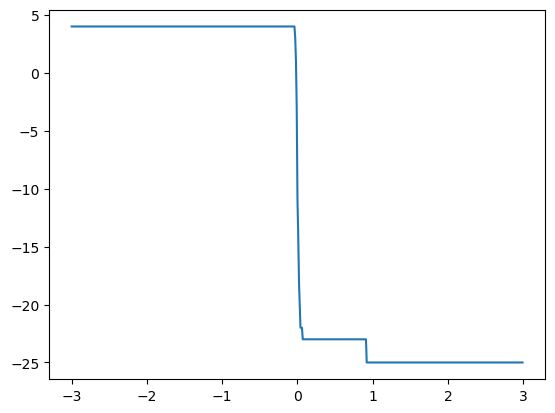

In [397]:
mean_vs_beta = []
beta_range = np.arange(-3, 3, 0.01)
sim_params["conv_size"] = 1000

for beta in beta_range:
    params["beta"] = beta
    integration_kernel = init_1D_kernel(params, sim_params, "beta", exponent=1)
    integration_probability = convolve(nh, integration_kernel, mode="same")
    integration_probability = integration_probability*n/np.sum(integration_probability*n)
    ind_max = np.argmax(integration_probability)

    mean_vs_beta.append(xdomain[ind_max])

plt.plot(beta_range, mean_vs_beta)

(-2000.0, 1000.0)

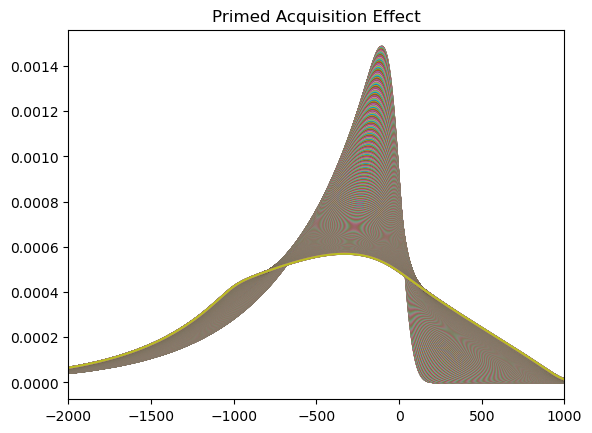

In [79]:
# plt.plot(xdomain, n/np.sum(n), label = "Phage Population")

from scipy.signal import convolve
sim_params["conv_size"]= 1000

beta_list = np.arange(1, 1000, 1)
for beta in beta_list:
    params["beta"] = 1/beta
    integration_kernel = init_1D_kernel(params, sim_params, "beta")
    integration_probability = convolve(nh, integration_kernel, mode="same")
    integration_probability = integration_probability/np.sum(integration_probability)
    plt.plot(xdomain, integration_probability)

plt.title("Primed Acquisition Effect")
plt.xlim(-2000, 1000)

(-2000.0, 1000.0)

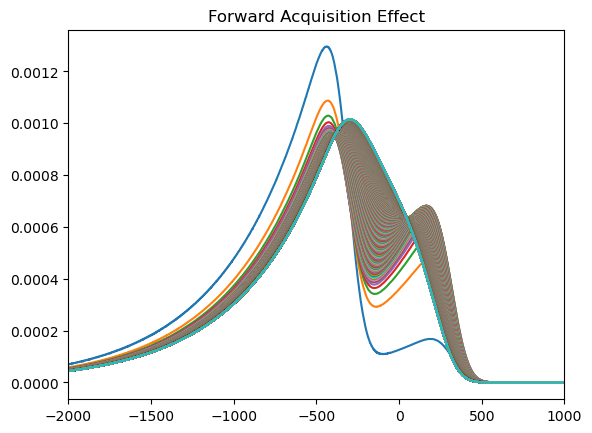

In [172]:
from scipy.signal import convolve
sim_params["conv_size"]= 1000

beta_list = np.arange(0.5, 1000, 1)
for beta in beta_list:
    params["beta"] = -1/beta
    integration_kernel = init_1D_kernel(params, sim_params, "beta")
    integration_probability = convolve(nh, integration_kernel, mode="same")
    integration_probability = integration_probability/np.sum(integration_probability)
    plt.plot(xdomain, integration_probability)

plt.title("Forward Acquisition Effect")
plt.xlim(-2000, 1000)

Text(0, 0.5, 'Probability')

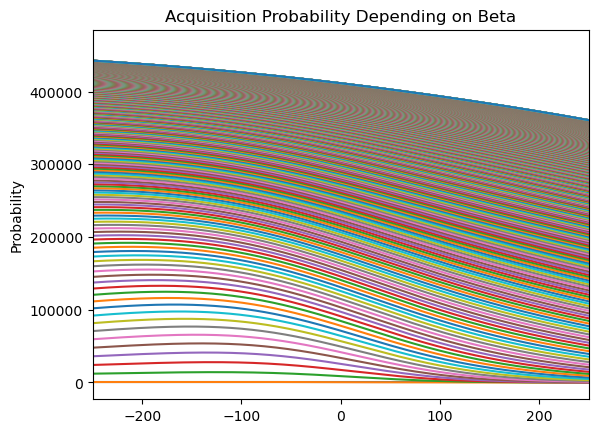

In [ ]:
plt.plot(xdomain, n/np.sum(n), label = "Phage Population")
mean_beta = []

beta_list = np.arange(0.1, 10000, 10)
for beta in beta_list:
    params["beta"] = 1/beta
    integration_kernel = init_1D_kernel(params, sim_params, "beta")
    integration_probability = convolve(nh, integration_kernel, mode="same")
    integration_n = integration_probability*n/np.sum(integration_probability*n)
    mean_beta.append(fit_gaussian(xdomain, integration_n)[1])

    plt.plot(xdomain, integration_n, label = f"beta = {beta}")
    # plt.vlines(0 + 1/beta, 0, 0.007)

# beta_list = np.arange(0.5, 1000, 10)
# for beta in beta_list:
#     params["beta"] = -1/beta
#     integration_kernel = init_1D_kernel(params, sim_params, "beta")
#     integration_probability = convolve(nh, integration_kernel, mode="same")
#     integration_probability = integration_probability*n/np.sum(integration_probability*n)

#     plt.plot(xdomain, integration_probability, label = f"beta = {beta}")
# plt.legend()
plt.xlim(-250, 250)
plt.title("Acquisition Probability Depending on Beta")
plt.ylabel("Probability")

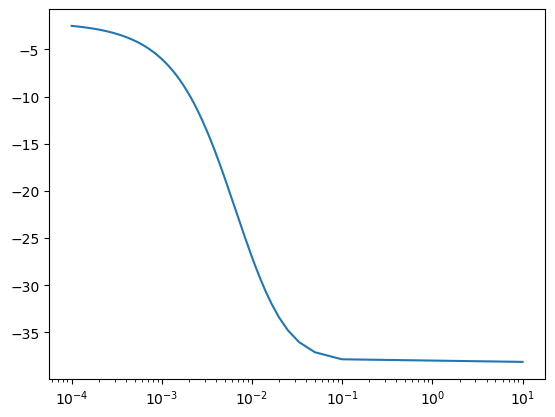

In [189]:
plt.plot(1/beta_list, mean_beta)
plt.xscale("log")

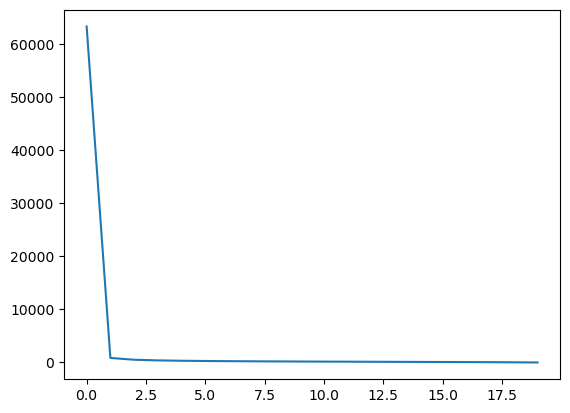

In [180]:
from scipy.special import erfcinv

sigma = params["sigma"]
beta_list = np.arange(0.1, 1000, 10)
mode = []
for inv_beta in beta_list:
    beta = 1/inv_beta

    c = (np.abs(inv_beta)/sigma)*np.sqrt(2/np.pi)
    X = np.sign(inv_beta)*np.sqrt(2)*sigma*erfcinv(c) + np.power(sigma, 2)/inv_beta
    mode.append(X)

plt.plot(mode)

Text(0, 0.5, 'Probability')

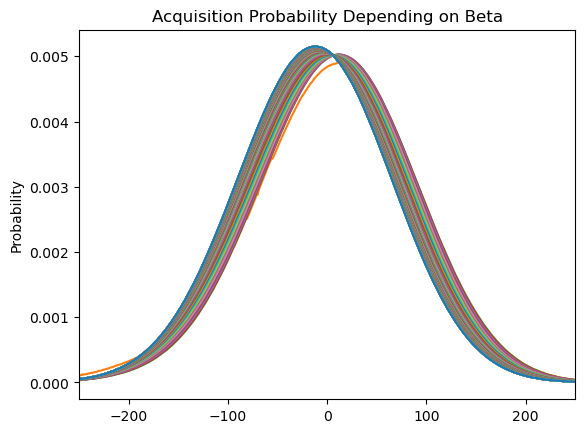

In [171]:
plt.plot(xdomain, n/np.sum(n), label = "Phage Population")

beta_list = np.arange(0.5, 1000, 10)
for beta in beta_list:
    params["beta"] = -1/beta
    integration_kernel = init_1D_kernel(params, sim_params, "beta")
    integration_probability = convolve(nh, integration_kernel, mode="same")
    integration_probability = integration_probability*n/np.sum(integration_probability*n)

    plt.plot(xdomain, integration_probability, label = f"beta = {beta}")

# plt.legend()
plt.xlim(-250, 250)
plt.title("Acquisition Probability Depending on Beta")
plt.ylabel("Probability")

In [157]:
from scipy.signal import convolve

params["beta"] = 100
integration_kernel = init_1D_kernel(params, sim_params, "beta")
integration_probability = convolve(nh, integration_kernel, mode="same")

nh_primed = immunity_mean_field_add(nh, n, params, sim_params, int_prob = integration_probability)

nh_null = immunity_mean_field_add(nh, n, params, sim_params)

params["beta"] = -2
integration_kernel = init_1D_kernel(params, sim_params, "beta")
integration_probability = convolve(nh, integration_kernel, mode="same")
nh_unprimed = immunity_mean_field_add(nh, n, params, sim_params, int_prob = integration_probability)

(-200.0, 200.0)

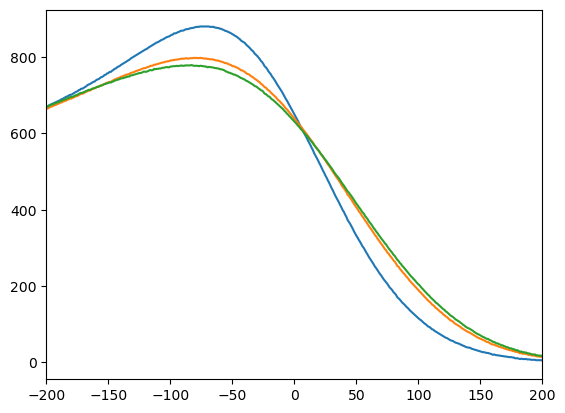

In [158]:
plt.plot(xdomain, nh_primed, label = "Primed")
plt.plot(xdomain, nh_null, label="Base")
plt.plot(xdomain, nh_unprimed, label="Base")
plt.xlim(-200, 200)

(-500.0, 500.0)

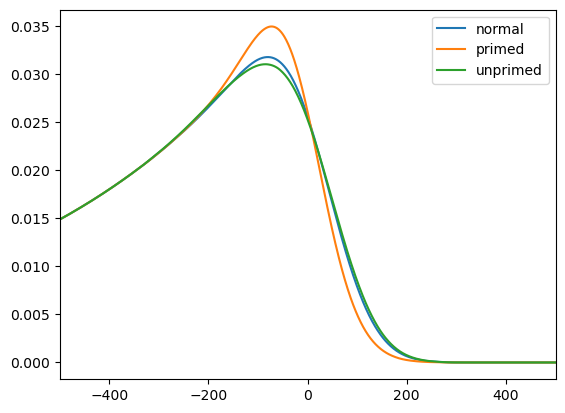

In [160]:
params["r"] = 10
kernel_1D = init_1D_kernel(params, sim_params, "coverage")
p = coverage_1D(nh_null, kernel_1D, params, sim_params)

params["r"] = 10
kernel_1D = init_1D_kernel(params, sim_params, "coverage")
p_primed = coverage_1D(nh_primed, kernel_1D, params, sim_params)

params["r"] = 10
kernel_1D = init_1D_kernel(params, sim_params, "coverage")
p_unprimed = coverage_1D(nh_unprimed, kernel_1D, params, sim_params)

plt.plot(xdomain, p, label = "normal")
plt.plot(xdomain, p_primed, label = "primed")
plt.plot(xdomain, p_unprimed, label = "unprimed")
plt.legend()
plt.xlim(-500, 500)

In [263]:
fit_gaussian(xdomain, integration_probability)

array([ 0.99793384,  4.1688227 , 49.14060892])

In [281]:
beta_range = np.arange(-1, 10, 0.25)
size_range = np.arange(1, 11)
seperation_distance = np.zeros([len(beta_range), len(size_range)])
variance_matrix = np.zeros([len(beta_range), len(size_range)])

for i, beta in enumerate(beta_range):
    for j, size in enumerate(size_range):
        kernel = beta
        conv_ker_size = np.rint(size*params["sigma"]).astype(int)

        x_linspace = np.arange(-conv_ker_size, conv_ker_size, 1)

        exp_radius = np.power(np.abs(x_linspace), 1)
        kernel_1D = np.exp(-exp_radius*kernel)

        integration_probability = convolve(nh, kernel_1D, mode="same")
        integration_probability = integration_probability*n/np.sum(integration_probability*n)
        popt = fit_gaussian(xdomain, integration_probability)
        seperation_distance[i, j] = popt[1]
        variance_matrix[i, j] = popt[2]

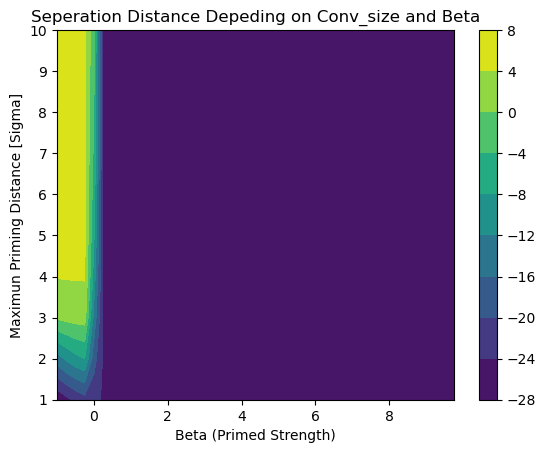

In [282]:
plt.contourf(beta_range, size_range, seperation_distance.transpose())
plt.xlabel("Beta (Primed Strength)")
plt.ylabel("Maximun Priming Distance [Sigma]")
plt.title("Seperation Distance Depeding on Conv_size and Beta")
plt.colorbar()

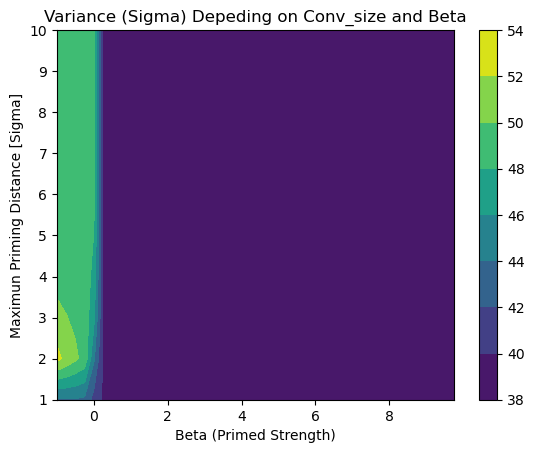

In [283]:
plt.contourf(beta_range, size_range, variance_matrix.transpose())
plt.xlabel("Beta (Primed Strength)")
plt.ylabel("Maximun Priming Distance [Sigma]")
plt.title("Variance (Sigma) Depeding on Conv_size and Beta")
plt.colorbar()